
#Problem 3 :  Particle Falling Through a Viscous Medium  


To study the motion of a particle falling vertically under gravity in a viscous medium,we have to compare
Euler’s numerical solution with the analytical solution, and analyse the effect of drag.

## Given
- Drag force:  
  $$
  F_{\text{drag}} = -bv
  $$

- Ratio of drag coefficient to mass:  
  $$
  \frac{b}{m} = 2.0 \,\text{s}^{-1}
  $$

- Acceleration due to gravity:  
  $$
  g = 10 \,\text{m/s}^2
  $$

- Initial position:  
  $$
  x(0) = 10 \,\text{m}
  $$

- Initial velocity:  
  $$
  v(0) = 0 \,\text{m/s}
  $$

- Time interval:  
  $$
  0 \le t \le 3 \,\text{s}
  $$


A particle is falling vertically under gravity through a viscous medium.
Two forces act on the particle:

1. **Gravitational force** acting downward:  
   $$
   F_g =  +mg
   $$

2. **Viscous drag force** acting upward:  
   $$
   F_{\text{drag}} = -bv
   $$

Using Newton’s second law:
$$
m\frac{dv}{dt} = mg - bv
$$

$$
\frac{dv}{dt} = g - \frac{b}{m}v
$$

Substituting given values:
$$
{\frac{dv}{dt} = 10 - 2v}
$$
## -> Analytical Solution for Velocity

The differential equation is:
$$
\frac{dv}{dt} + 2v = 10
$$

This is a first-order linear differential equation.

$$
\frac{dv}{10 - 2v} = dt
$$

$$
\int \frac{dv}{10 - 2v} = \int dt
$$

Let \( u = 10 - 2v \), then \( du = -2\,dv \)

$$
-\frac{1}{2} \int \frac{du}{u} = \int dt
$$

$$
-\frac{1}{2}\ln|10 - 2v| = t + C
$$

$$
\ln|10 - 2v| = -2t + C
$$

$$
10 - 2v = Ce^{-2t}
$$



$$
{v(t) = 5 + Ce^{-2t}}
$$

Using initial condition \(v(0) = 0\):
$$
C = -5
$$

Final velocity expression:
$$
\boxed{v(t) = 5(1 - e^{-2t})}
$$

The terminal velocity is(when t tends to infinity):
$$
v_{\text{terminal}} = 5\,\text{m/s}
$$



## Analytical Solution for Position

Velocity is:
$$
v(t) = \frac{dx}{dt} = 5(1 - e^{-2t})
$$
$$
x(t) = 5t - \frac{5}{2}(1 - e^{-2t}) + C
$$

Using initial condition \(x(0) = 10\):
$$
C = 10
$$

Final position expression:
$$
\boxed{x(t) = 10 + 5t - \frac{5}{2}(1 - e^{-2t})}
$$

In [13]:
import numpy as np
import matplotlib.pyplot as plt


In [14]:
# Given constants
g = 10
b_over_m = 2

def analytical_solution(t):
    v = (g / b_over_m) * (1 - np.exp(-b_over_m * t))
    x = 10 + (g / b_over_m) * t - (g / b_over_m**2) * (1 - np.exp(-b_over_m * t))
    return x, v


## Euler’s Method

Euler’s method approximates solutions of differential equations using:
$$
v_{i+1} = v_i + a_i \Delta t
$$
$$
x_{i+1} = x_i + v_i \Delta t
$$

Where:
$$
a_i = 10 - 2v_i
$$

The time step is:
$$
\Delta t = \frac{3}{n}
$$


In [15]:
def euler_method(n, b_over_m=2):
    t = np.linspace(0, 3, n+1)
    dt = t[1] - t[0]

    x = np.zeros(n+1)
    v = np.zeros(n+1)

    x[0] = 10
    v[0] = 0

    for i in range(n):
        a = g - b_over_m * v[i]
        v[i+1] = v[i] + a * dt
        x[i+1] = x[i] + v[i] * dt

    return t, x, v


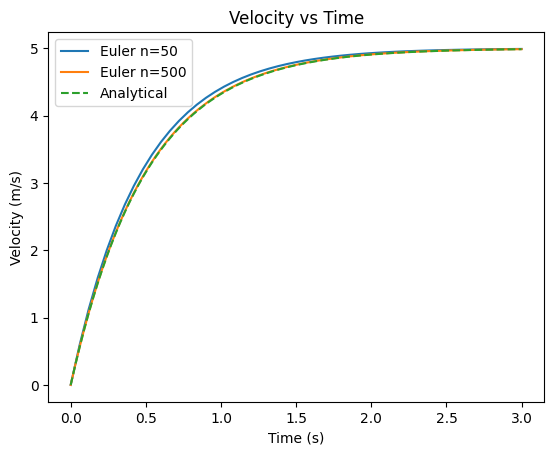

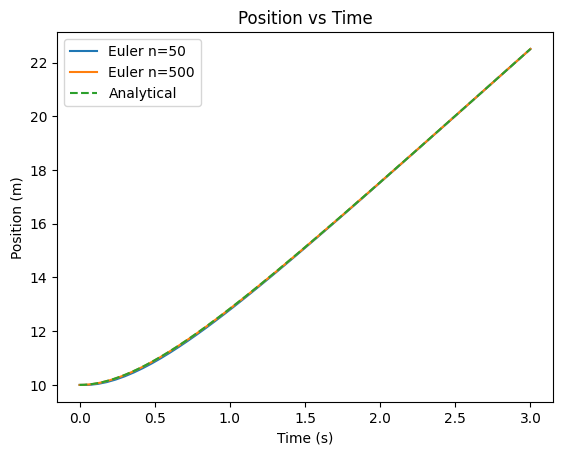

In [16]:

# Euler solutions
t50, x50, v50 = euler_method(50)
t500, x500, v500 = euler_method(500)

# Analytical solution
xA, vA = analytical_solution(t500)

# Velocity plot
plt.figure()
plt.plot(t50, v50, label="Euler n=50")
plt.plot(t500, v500, label="Euler n=500")
plt.plot(t500, vA, '--', label="Analytical")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.title("Velocity vs Time")
plt.show()

# Position plot
plt.figure()
plt.plot(t50, x50, label="Euler n=50")
plt.plot(t500, x500, label="Euler n=500")
plt.plot(t500, xA, '--', label="Analytical")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.legend()
plt.title("Position vs Time")
plt.show()


## Accuracy Comparison

- For **n = 50**, Euler’s method shows noticeable deviation due to larger time step.
- For **n = 500**, numerical results almost overlap with analytical solution.
- Smaller step size improves accuracy.

Thus, Euler’s method converges to the analytical solution Δt tends to 0.

## One observation
In Velocity vs Time plot, for small n and bigger n we see a difference ( or maybe we can say error ) in Euler's method and analytical solution, but for Position vs Time plot even for small n , both curves are almost same ( error tending to 0). This happens because Euler's method directly approximates the velocity, so the error is visible but position is the integration of velocity, so basically smoothes out the error.


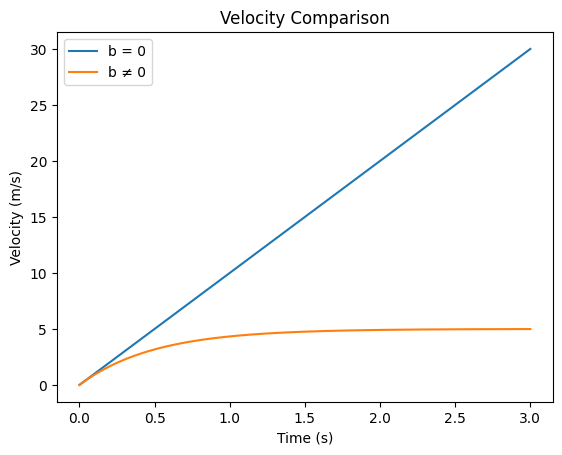

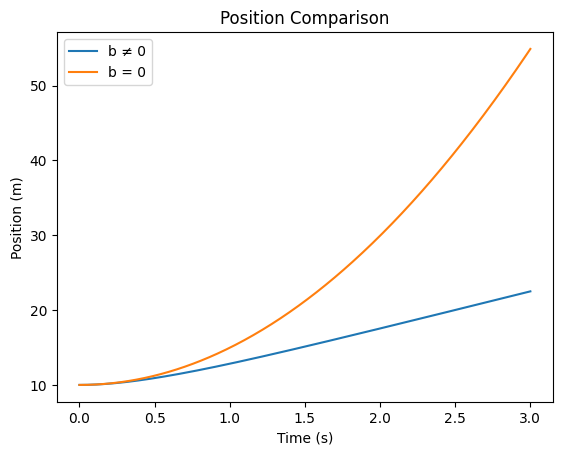

In [17]:
#when b = 0 or no drag force in the medium, basically a free fall where no terminal velocity is gained and velocity increases indefinitely.
t_b0, x_b0, v_b0 = euler_method(500, b_over_m=0)

plt.figure()
plt.plot(t_b0, v_b0, label="b = 0")
plt.plot(t500, v500, label="b ≠ 0")
plt.xlabel("Time (s)")
plt.ylabel("Velocity (m/s)")
plt.legend()
plt.title("Velocity Comparison")
plt.show()

plt.figure()
plt.plot(t500, x500, label="b ≠ 0")
plt.plot(t_b0, x_b0, label="b = 0")
plt.xlabel("Time (s)")
plt.ylabel("Position (m)")
plt.title("Position Comparison")
plt.legend()
plt.show()


## Physical Interpretation

### Velocity Analysis
- For **b = 0 (no drag)**, the particle undergoes uniform acceleration due to gravity(free fall).
  The velocity increases linearly with time and does not approach any limiting value.
- For **b = 2 (with drag)**, the viscous force opposes motion and increases with velocity.
  As a result, the acceleration becomes zero and velocity reaches a terminal value.

  ### Position Analysis
- For **b = 0 (no drag)**, the continuously increasing velocity leads to a rapidly
  increasing displacement. The position–time curve is parabolic in nature.
- For **b = 2 (with drag)**, the reduction in acceleration limits the rate of increase
  of position. The position–time curve grows more slowly and tends towards a nearly linear
  behaviour at later times.
